https://www.kaggle.com/datasets/kaushalnandania/credit-card-fraud-detection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
#load dataset
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
## Keep only useful columns
keep_cols = ["trans_date_trans_time", "amt", "category", "gender", "city_pop",
    "job", "lat", "long", "merch_lat", "merch_long", "unix_time",
    "merchant", "state", "dob", "is_fraud"]

train_df = train_df[keep_cols].copy()
test_df = test_df[keep_cols].copy()

In [ ]:
#feature engineering
def preprocess(df):
  df = df.copy()

  #transaction time features
  df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
  df["hour"] = df["trans_date_trans_time"].dt.hour
  df["day"] = df["trans_date_trans_time"].dt.day
  df["month"] = df["trans_date_trans_time"].dt.month
  df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

  # age from date of birth
  df["dob"] = pd.to_datetime(df["dob"], errors="coerce")
  df["age"] = 2020 - df["dob"].dt.year

  #simple location difference features
  df["lat_diff"] = np.abs(df["lat"] - df["merch_lat"])
  df["long_diff"] = np.abs(df["long"] - df["merch_long"])

  #drop raw date columns
  df.drop(columns=["trans_date_trans_time", "dob"], inplace=True)

  return df

train_df = preprocess(train_df)
test_df = preprocess(test_df)


In [ ]:
# categorical columns
cat_cols = ["category", "gender", "job", "merchant", "state"]

for col in cat_cols:
  train_df[col], uniques = pd.factorize(train_df[col])
  mapping = {v: i for i, v in enumerate(uniques)}
  test_df[col] = test_df[col].map(mapping).fillna(-1).astype(int)



In [ ]:
from sklearn.ensemble._hist_gradient_boosting.grower import X_BITSET_INNER_DTYPE
# split features
X_train = train_df.drop(columns=["is_fraud"])
y_train = train_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

In [ ]:
# train model
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train, sample_weight=sample_weights)

HistGradientBoostingClassifier(max_depth=8, random_state=42)

In [ ]:
# predict/evaluate
y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

print("\nConfusion matrix: ")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report: ")
print(classification_report(y_test, y_pred))

Accuracy:  0.9868098805331471
Precision:  0.22102657914559345
Recall:  0.9575757575757575
F1 Score:  0.35915369819898585

Confusion matrix: 
[[546335   7239]
 [    91   2054]]

Classification report: 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.22      0.96      0.36      2145

    accuracy                           0.99    555719
   macro avg       0.61      0.97      0.68    555719
weighted avg       1.00      0.99      0.99    555719



The initial `HistGradientBoostingClassifier` model, trained with class weights to handle the imbalanced dataset, shows a high recall (0.96) for fraudulent transactions, which is good for catching fraud. However, the precision is quite low (0.22), meaning a large number of legitimate transactions are incorrectly flagged as fraudulent (false positives). The F1-score of 0.36 indicates a poor balance between precision and recall. This suggests that while the model is good at identifying most fraud cases, it also generates many false alarms, which can be costly and inconvenient. Our goal is to improve the precision while maintaining a good recall.

In [ ]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

threshold = 0.8  # Example: Increase the threshold to 0.8
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

print(f"--- Metrics with threshold = {threshold} ---")
print("Accuracy: ", accuracy_score(y_test, y_pred_adjusted))
print("Precision: ", precision_score(y_test, y_pred_adjusted))
print("Recall: ", recall_score(y_test, y_pred_adjusted))
print("F1 Score: ", f1_score(y_test, y_pred_adjusted))

print("\nConfusion matrix: ")
print(confusion_matrix(y_test, y_pred_adjusted))

print("\nClassification report: ")
print(classification_report(y_test, y_pred_adjusted))

--- Metrics with threshold = 0.8 ---
Accuracy:  0.9950010706850044
Precision:  0.4304242690701253
Recall:  0.9128205128205128
F1 Score:  0.585001493875112

Confusion matrix: 
[[550983   2591]
 [   187   1958]]

Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.43      0.91      0.59      2145

    accuracy                           1.00    555719
   macro avg       0.72      0.95      0.79    555719
weighted avg       1.00      1.00      1.00    555719



As you can see, increasing the threshold to `0.8` significantly improved precision, but it reduced recall. There's always a trade-off between precision and recall. You need to decide which metric is more critical for your specific use case. For fraud detection, you might want to prioritize recall to catch as many fraudulent transactions as possible, or balance it with precision to avoid too many false alarms.

We can also visualize the precision-recall curve to better understand this trade-off.

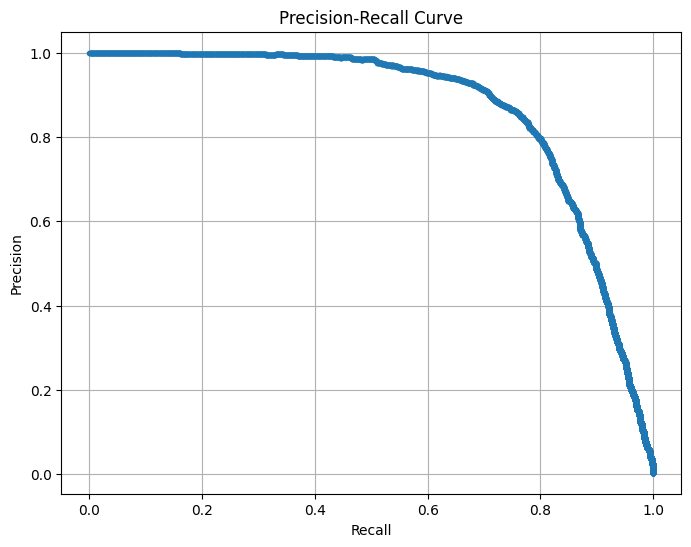

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

The Precision-Recall curve helps you visualize the trade-off. You can then choose a threshold that balances precision and recall based on your business requirements. For example, you might want to find a threshold that gives you a certain level of precision while maintaining an acceptable recall. You can also look into other techniques like using different evaluation metrics (e.g., F2-score if recall is more important), collecting more data, or trying different models or advanced sampling techniques.

In [ ]:
## SMOTE MODEL
import warnings
warnings.filterwarnings('ignore') # Filter out warnings that might arise from imblearn

from imblearn.over_sampling import SMOTE

print('Original dataset shape %s' % y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Resampled dataset shape %s' % y_train_res.value_counts())

Original dataset shape is_fraud
0    1289169
1       7506
Name: count, dtype: int64
Resampled dataset shape is_fraud
0    1289169
1    1289169
Name: count, dtype: int64


In [ ]:
# Predict probabilities with the SMOTE-trained model
y_pred_proba_smote = model_smote.predict_proba(X_test)[:, 1]

# Adjust threshold for the SMOTE-trained model
threshold_smote = 0.8 # Example: Try a high threshold initially
y_pred_adjusted_smote = (y_pred_proba_smote >= threshold_smote).astype(int)

print(f"--- Metrics for SMOTE model with threshold = {threshold_smote} ---")
print("Accuracy: ", accuracy_score(y_test, y_pred_adjusted_smote))
print("Precision: ", precision_score(y_test, y_pred_adjusted_smote))
print("Recall: ", recall_score(y_test, y_pred_adjusted_smote))
print("F1 Score: ", f1_score(y_test, y_pred_adjusted_smote))

print("\nConfusion matrix: ")
print(confusion_matrix(y_test, y_pred_adjusted_smote))

print("\nClassification report: ")
print(classification_report(y_test, y_pred_adjusted_smote))

--- Metrics for SMOTE model with threshold = 0.8 ---
Accuracy:  0.9890916092485591
Precision:  0.23291967816718942
Recall:  0.7962703962703963
F1 Score:  0.3604135893648449

Confusion matrix: 
[[547949   5625]
 [   437   1708]]

Classification report: 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.23      0.80      0.36      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.89      0.68    555719
weighted avg       1.00      0.99      0.99    555719



After training the model with SMOTE-resampled data and evaluating it with a threshold of 0.8, we observe that the precision has slightly increased to 0.23 (from 0.22 in the initial model). However, the recall has decreased to 0.80 (from 0.96), and the F1-score remains similar at 0.36. This indicates that while SMOTE helped to balance the dataset during training, simply applying a high threshold like 0.8 does not necessarily lead to a better balance between precision and recall, as it reduced the model's ability to catch fraudulent transactions.

In [ ]:
# Calculate F1 score for each threshold
f1_scores_smote = (2 * precision_smote * recall_smote) / (precision_smote + recall_smote)

# Find the threshold that maximizes the F1 score
optimal_f1_idx_smote = np.argmax(f1_scores_smote)
optimal_threshold_smote = thresholds_smote[optimal_f1_idx_smote]

print(f"Optimal threshold for SMOTE model based on F1-score: {optimal_threshold_smote:.4f}")

# Apply the optimal threshold
y_pred_optimal_smote = (y_pred_proba_smote >= optimal_threshold_smote).astype(int)

print(f"\n--- Metrics for SMOTE model with optimal threshold = {optimal_threshold_smote:.4f} ---")
print("Accuracy: ", accuracy_score(y_test, y_pred_optimal_smote))
print("Precision: ", precision_score(y_test, y_pred_optimal_smote))
print("Recall: ", recall_score(y_test, y_pred_optimal_smote))
print("F1 Score: ", f1_score(y_test, y_pred_optimal_smote))

print("\nConfusion matrix: ")
print(confusion_matrix(y_test, y_pred_optimal_smote))

print("\nClassification report: ")
print(classification_report(y_test, y_pred_optimal_smote))

Optimal threshold for SMOTE model based on F1-score: 0.9657

--- Metrics for SMOTE model with optimal threshold = 0.9657 ---
Accuracy:  0.9973025935769697
Precision:  0.668054110301769
Recall:  0.5986013986013986
F1 Score:  0.631423653798869

Confusion matrix: 
[[552936    638]
 [   861   1284]]

Classification report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.67      0.60      0.63      2145

    accuracy                           1.00    555719
   macro avg       0.83      0.80      0.82    555719
weighted avg       1.00      1.00      1.00    555719



By finding the threshold that maximizes the F1-score, we've adjusted the `model_smote` to its best-balanced performance. Compare these results with the previous ones to see the impact of threshold optimization. You can further fine-tune the threshold if a different balance of precision and recall is desired, or consider other advanced techniques for imbalanced classification if the F1-score is still not satisfactory.

After retraining with SMOTE, we observed a significant drop in precision and F1-score with the default threshold. Let's visualize the Precision-Recall curve for this new model (`model_smote`) to understand the trade-off and identify a potentially better threshold.

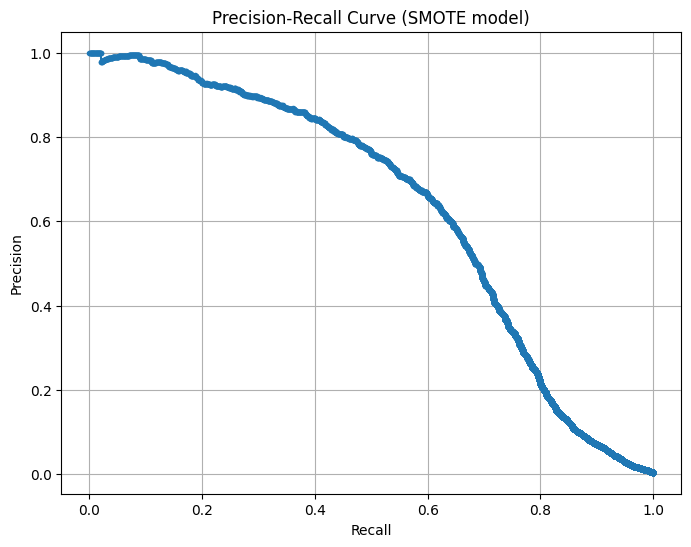

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_smote, recall_smote, thresholds_smote = precision_recall_curve(y_test, y_pred_proba_smote)

plt.figure(figsize=(8, 6))
plt.plot(recall_smote, precision_smote, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (SMOTE model)')
plt.grid(True)
plt.show()

The Precision-Recall curve for the SMOTE-trained model gives us a visual representation of how different thresholds affect performance. You can now use this curve to select a threshold that best balances precision and recall according to your specific needs. For instance, you might look for the point on the curve where both precision and recall are relatively high, or prioritize one over the other based on the cost implications of false positives vs. false negatives. If you identify a desired point on the curve, you can then find the corresponding threshold value and apply it to `y_pred_proba_smote` to get the desired classifications.